In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import onnxruntime as ort
import numpy as np

In [3]:
model_path = '/export2/obasit/ClusterLevelServing/vllm_profiler_logs/latency_model/'
est = ort.InferenceSession(model_path + "unified_latency_model.onnx")

In [4]:
def infer_prefill(model, tokens, tp, freq):
    FEATURE_COLS = [
        'model',
        'prefill_batch_size', 'prefill_input_len_sum', 'prefill_input_len_mean', 'prefill_input_len_std',
        'decode_batch_size', 'decode_input_len_sum', 'decode_input_len_mean', 'decode_input_len_std',
        'tp_degree', 'freq_mhz'
    ]

    X = pd.DataFrame([{
        "prefill_batch_size": len(tokens),
        "prefill_input_len_sum": sum(tokens),
        "prefill_input_len_mean": float(np.mean(tokens)),
        "prefill_input_len_std": float(np.std(tokens)),
        "decode_batch_size": 0,
        "decode_input_len_sum": 0,
        "decode_input_len_mean": 0,
        "decode_input_len_std": 0,
        "tp_degree": tp,
        "freq_mhz": freq,
        "model": "Llama-3.3-70B-Instruct"
    }], columns=FEATURE_COLS)


    input_feed = {}
    for col in FEATURE_COLS:
        val = X[col].values.reshape(-1, 1)
        if X[col].dtype == object or col == "model":
            input_feed[col] = val.astype(str)
        else:
            input_feed[col] = val.astype("float32")

    inputs = input_feed
    outputs = model.run(None, inputs)
    return outputs

def infer_decode(model, tokens, tp, freq):
    FEATURE_COLS = [
        'model',
        'prefill_batch_size', 'prefill_input_len_sum', 'prefill_input_len_mean', 'prefill_input_len_std',
        'decode_batch_size', 'decode_input_len_sum', 'decode_input_len_mean', 'decode_input_len_std',
        'tp_degree', 'freq_mhz'
    ]

    X = pd.DataFrame([{
        "prefill_batch_size": 0,
        "prefill_input_len_sum": 0,
        "prefill_input_len_mean": 0,
        "prefill_input_len_std": 0,
        "decode_batch_size": len(tokens),
        "decode_input_len_sum": sum(tokens),
        "decode_input_len_mean": float(np.mean(tokens)),
        "decode_input_len_std": float(np.std(tokens)),
        "tp_degree": tp,
        "freq_mhz": freq,
        "model": "Llama-3.3-70B-Instruct"
    }], columns=FEATURE_COLS)


    input_feed = {}
    for col in FEATURE_COLS:
        val = X[col].values.reshape(-1, 1)
        if X[col].dtype == object or col == "model":
            input_feed[col] = val.astype(str)
        else:
            input_feed[col] = val.astype("float32")

    inputs = input_feed
    outputs = model.run(None, inputs)
    return outputs

def infer_mixed(model, prefill_tokens, decode_tokens, tp, freq):
    FEATURE_COLS = [
        'model',
        'prefill_batch_size', 'prefill_input_len_sum', 'prefill_input_len_mean', 'prefill_input_len_std',
        'decode_batch_size', 'decode_input_len_sum', 'decode_input_len_mean', 'decode_input_len_std',
        'tp_degree', 'freq_mhz'
    ]

    X = pd.DataFrame([{
        "prefill_batch_size": len(prefill_tokens),
        "prefill_input_len_sum": sum(prefill_tokens),
        "prefill_input_len_mean": float(np.mean(prefill_tokens)),
        "prefill_input_len_std": float(np.std(prefill_tokens)),
        "decode_batch_size": len(decode_tokens),
        "decode_input_len_sum": sum(decode_tokens),
        "decode_input_len_mean": float(np.mean(decode_tokens)),
        "decode_input_len_std": float(np.std(decode_tokens)),
        "tp_degree": tp,
        "freq_mhz": freq,
        "model": "Llama-3.3-70B-Instruct"
    }], columns=FEATURE_COLS)


    input_feed = {}
    for col in FEATURE_COLS:
        val = X[col].values.reshape(-1, 1)
        if X[col].dtype == object or col == "model":
            input_feed[col] = val.astype(str)
        else:
            input_feed[col] = val.astype("float32")

    inputs = input_feed
    outputs = model.run(None, inputs)
    return outputs

# Prefill

## TP2

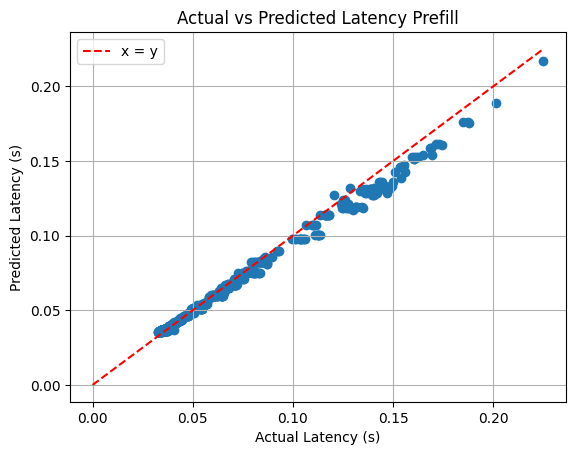

In [22]:
path = "/export1/liu3882/llm_energy/DistServe/my_script/eval_results_Oct12/tp2_logs_num1k/profiler_logs_seed1k_rps4_freq1080/meta-llama/Llama-3.3-70B-Instruct/H100/1xTP2Prefill_1xTP2/default_log_path/prefill_0_Oct13031340/engine_0.csv"
df_prefill = pd.read_csv(path)


df_prefill['num_prompt_tokens_reqs_evald'] = df_prefill['num_prompt_tokens_reqs'].apply(eval)

# drop empty rows first
df_prefill = df_prefill[df_prefill['num_prompt_tokens_reqs_evald'].apply(lambda x: len(x) > 0)].copy()
# then do shift of gpu times
df_prefill.loc[:, "step_with_batch_queue_time_ms"] = df_prefill["step_with_batch_queue_time_ms_1_iters_delay"].shift(-1)

token_lists = df_prefill['num_prompt_tokens_reqs_evald'].tolist()
latency_lists = (df_prefill['step_with_batch_queue_time_ms'] / 1000.0).tolist()

predicted_latencies = [infer_prefill(est, tokens, 2, 1080)[0][0][0] for tokens in token_lists]

plt.scatter(latency_lists, predicted_latencies)
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')
plt.legend()
plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency Prefill")
plt.grid(True)
plt.show()

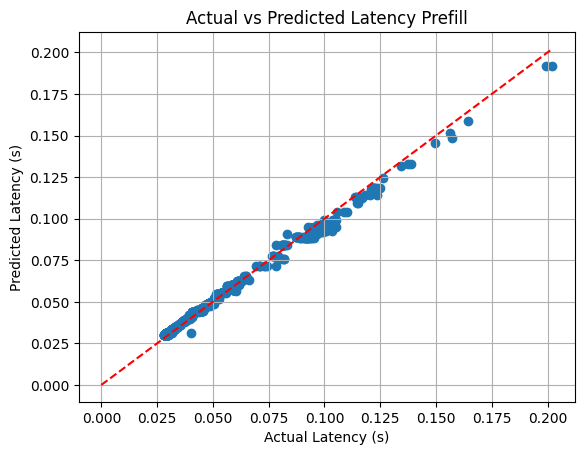

In [23]:
path = "/export1/liu3882/llm_energy/DistServe/my_script/eval_results_Oct12/tp2_logs_num1k/profiler_logs_seed1k_rps8_freq1980/meta-llama/Llama-3.3-70B-Instruct/H100/1xTP2Prefill_1xTP2/default_log_path/prefill_0_Oct13022453/engine_0.csv"
df_prefill = pd.read_csv(path)


df_prefill['num_prompt_tokens_reqs_evald'] = df_prefill['num_prompt_tokens_reqs'].apply(eval)

# drop empty rows first
df_prefill = df_prefill[df_prefill['num_prompt_tokens_reqs_evald'].apply(lambda x: len(x) > 0)].copy()
# then do shift of gpu times
df_prefill.loc[:, "step_with_batch_queue_time_ms"] = df_prefill["step_with_batch_queue_time_ms_1_iters_delay"].shift(-1)

token_lists = df_prefill['num_prompt_tokens_reqs_evald'].tolist()
latency_lists = (df_prefill['step_with_batch_queue_time_ms'] / 1000.0).tolist()

predicted_latencies = [infer_prefill(est, tokens, 2, 1830)[0][0][0] for tokens in token_lists]
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')
plt.scatter(latency_lists, predicted_latencies)
plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency Prefill")
plt.grid(True)
plt.show()

## TP4

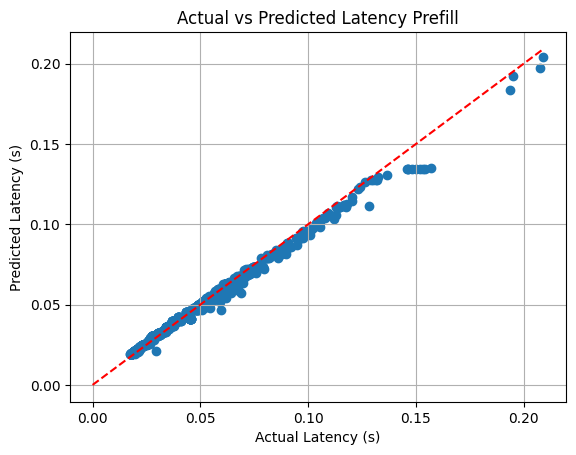

In [24]:
path = "/export1/liu3882/llm_energy/DistServe/my_script/eval_results_Oct12/tp4_logs_num4k/profiler_logs_seed1k_rps30_freq1980/meta-llama/Llama-3.3-70B-Instruct/H100/1xTP4Prefill_1xTP4/default_log_path/prefill_0_Oct13034118/engine_0.csv"
df_prefill = pd.read_csv(path)


df_prefill['num_prompt_tokens_reqs_evald'] = df_prefill['num_prompt_tokens_reqs'].apply(eval)

# drop empty rows first
df_prefill = df_prefill[df_prefill['num_prompt_tokens_reqs_evald'].apply(lambda x: len(x) > 0)].copy()
# then do shift of gpu times
df_prefill.loc[:, "step_with_batch_queue_time_ms"] = df_prefill["step_with_batch_queue_time_ms_1_iters_delay"].shift(-1)

token_lists = df_prefill['num_prompt_tokens_reqs_evald'].tolist()
latency_lists = (df_prefill['step_with_batch_queue_time_ms'] / 1000.0).tolist()

predicted_latencies = [infer_prefill(est, tokens, 4, 1830)[0][0][0] for tokens in token_lists]
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')

plt.scatter(latency_lists, predicted_latencies)
plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency Prefill")
plt.grid(True)
plt.show()

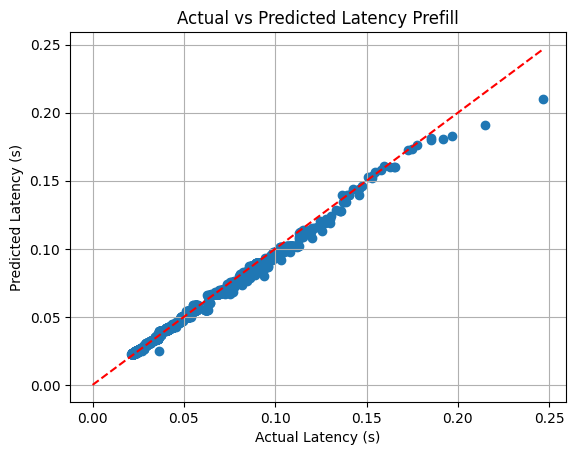

In [25]:
path = "/export1/liu3882/llm_energy/DistServe/my_script/eval_results_Oct12/tp4_logs_num4k/profiler_logs_seed1k_rps15_freq1080/meta-llama/Llama-3.3-70B-Instruct/H100/1xTP4Prefill_1xTP4/default_log_path/prefill_0_Oct13041652/engine_0.csv"
df_prefill = pd.read_csv(path)


df_prefill['num_prompt_tokens_reqs_evald'] = df_prefill['num_prompt_tokens_reqs'].apply(eval)

# drop empty rows first
df_prefill = df_prefill[df_prefill['num_prompt_tokens_reqs_evald'].apply(lambda x: len(x) > 0)].copy()
# then do shift of gpu times
df_prefill.loc[:, "step_with_batch_queue_time_ms"] = df_prefill["step_with_batch_queue_time_ms_1_iters_delay"].shift(-1)

token_lists = df_prefill['num_prompt_tokens_reqs_evald'].tolist()
latency_lists = (df_prefill['step_with_batch_queue_time_ms'] / 1000.0).tolist()

predicted_latencies = [infer_prefill(est, tokens, 4, 1080)[0][0][0] for tokens in token_lists]
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')

plt.scatter(latency_lists, predicted_latencies)
plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency Prefill")
plt.grid(True)
plt.show()

## TP8

# Decode

## TP2

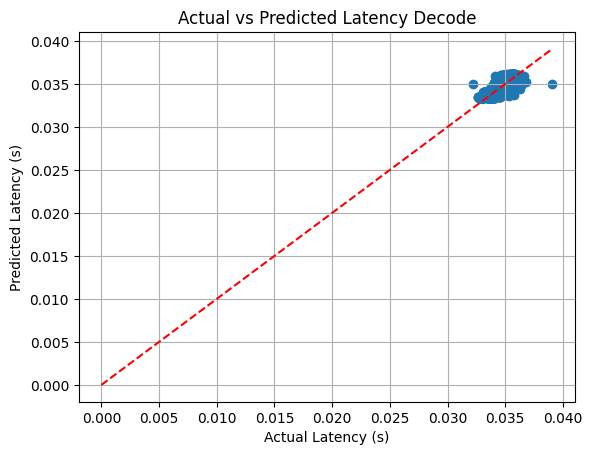

In [5]:
path = "/export1/liu3882/llm_energy/DistServe/my_script/eval_results_Oct12/tp2_logs_num1k/profiler_logs_seed1k_rps4_freq1080/meta-llama/Llama-3.3-70B-Instruct/H100/1xTP2Prefill_1xTP2/default_log_path/decode_2_Oct13031340/engine_0.csv"
df_decode = pd.read_csv(path)


df_decode['request_ids_iter_tbt_evald'] = df_decode['request_ids_iter_tbt'].apply(eval)
df_decode['inter_token_latencies_iter_evald'] = df_decode['inter_token_latencies_iter'].apply(eval)
df_decode['iter_lat'] = df_decode['inter_token_latencies_iter_evald'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else np.nan)
df_decode['num_prompt_tokens_reqs_evald'] = df_decode['num_prompt_tokens_reqs'].apply(eval)
num_computed_dict = {}
num_computed_tokens_list = [[] for _ in range(len(df_decode))]
#first get num_computed_tokens for each req in each row
for row in df_decode.itertuples():
    if len(row.request_ids_iter_tbt_evald) == 0:
        continue
    else:
        for ID, in_len in zip(row.request_ids_iter_tbt_evald, row.num_prompt_tokens_reqs_evald):
            if ID not in num_computed_dict:
                num_computed_dict[ID] = in_len + 1
            else:
                num_computed_dict[ID] = num_computed_dict[ID] + 1
        num_computed_tokens_list[row.Index] = [num_computed_dict[ID] for ID in row.request_ids_iter_tbt_evald]
df_decode['num_computed_tokens_reqs_evald'] = num_computed_tokens_list

token_lists = df_decode[df_decode['iter_lat'].notna() & df_decode['num_computed_tokens_reqs_evald'].notna()]['num_computed_tokens_reqs_evald'].tolist()
latency_lists = df_decode[df_decode['iter_lat'].notna() & df_decode['num_computed_tokens_reqs_evald'].notna()]['iter_lat'].tolist()

predicted_latencies = [infer_decode(est, tokens, 2, 1080)[0][0][0] for tokens in token_lists]

plt.scatter(latency_lists, predicted_latencies)
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')

plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency Decode")
plt.grid(True)
# plt.xlim(0, 0.05)
# plt.ylim(0, 0.05)
plt.show()

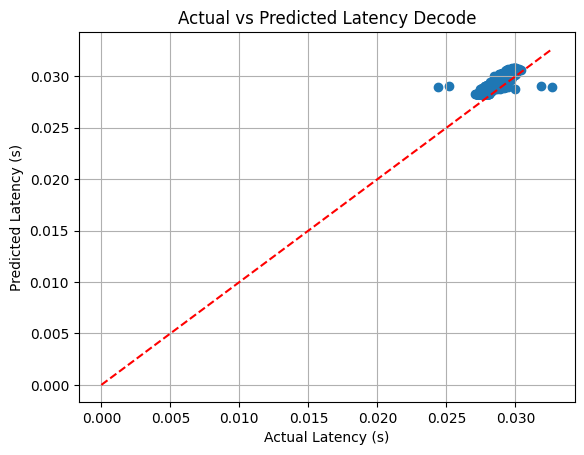

In [6]:
path = "/export1/liu3882/llm_energy/DistServe/my_script/eval_results_Oct12/tp2_logs_num1k/profiler_logs_seed1k_rps4_freq1980/meta-llama/Llama-3.3-70B-Instruct/H100/1xTP2Prefill_1xTP2/default_log_path/decode_2_Oct13023143/engine_0.csv"
df_decode = pd.read_csv(path)


df_decode['request_ids_iter_tbt_evald'] = df_decode['request_ids_iter_tbt'].apply(eval)
df_decode['inter_token_latencies_iter_evald'] = df_decode['inter_token_latencies_iter'].apply(eval)
df_decode['iter_lat'] = df_decode['inter_token_latencies_iter_evald'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else np.nan)
df_decode['num_prompt_tokens_reqs_evald'] = df_decode['num_prompt_tokens_reqs'].apply(eval)
num_computed_dict = {}
num_computed_tokens_list = [[] for _ in range(len(df_decode))]
#first get num_computed_tokens for each req in each row
for row in df_decode.itertuples():
    if len(row.request_ids_iter_tbt_evald) == 0:
        continue
    else:
        for ID, in_len in zip(row.request_ids_iter_tbt_evald, row.num_prompt_tokens_reqs_evald):
            if ID not in num_computed_dict:
                num_computed_dict[ID] = in_len + 1
            else:
                num_computed_dict[ID] = num_computed_dict[ID] + 1
        num_computed_tokens_list[row.Index] = [num_computed_dict[ID] for ID in row.request_ids_iter_tbt_evald]
df_decode['num_computed_tokens_reqs_evald'] = num_computed_tokens_list

token_lists = df_decode[df_decode['iter_lat'].notna() & df_decode['num_computed_tokens_reqs_evald'].notna()]['num_computed_tokens_reqs_evald'].tolist()
latency_lists = df_decode[df_decode['iter_lat'].notna() & df_decode['num_computed_tokens_reqs_evald'].notna()]['iter_lat'].tolist()

predicted_latencies = [infer_decode(est, tokens, 2, 1830)[0][0][0] for tokens in token_lists]

plt.scatter(latency_lists, predicted_latencies)
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')

plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency Decode")
plt.grid(True)
# plt.xlim(0, 0.05)
# plt.ylim(0, 0.05)
plt.show()

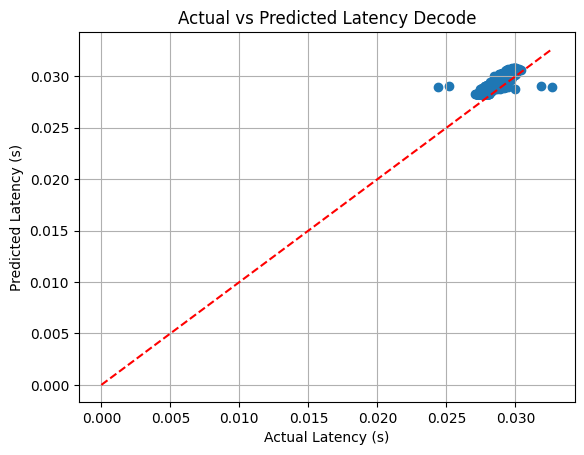

In [ ]:
path = "/export1/liu3882/llm_energy/DistServe/my_script/eval_results_Oct12/tp2_logs_num1k/profiler_logs_seed1k_rps4_freq1980/meta-llama/Llama-3.3-70B-Instruct/H100/1xTP2Prefill_1xTP2/default_log_path/decode_2_Oct13023143/engine_0.csv"
df_decode = pd.read_csv(path)


df_decode['request_ids_iter_tbt_evald'] = df_decode['request_ids_iter_tbt'].apply(eval)
df_decode['inter_token_latencies_iter_evald'] = df_decode['inter_token_latencies_iter'].apply(eval)
df_decode['iter_lat'] = df_decode['inter_token_latencies_iter_evald'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else np.nan)
df_decode['num_prompt_tokens_reqs_evald'] = df_decode['num_prompt_tokens_reqs'].apply(eval)
num_computed_dict = {}
num_computed_tokens_list = [[] for _ in range(len(df_decode))]
#first get num_computed_tokens for each req in each row
for row in df_decode.itertuples():
    if len(row.request_ids_iter_tbt_evald) == 0:
        continue
    else:
        for ID, in_len in zip(row.request_ids_iter_tbt_evald, row.num_prompt_tokens_reqs_evald):
            if ID not in num_computed_dict:
                num_computed_dict[ID] = in_len + 1
            else:
                num_computed_dict[ID] = num_computed_dict[ID] + 1
        num_computed_tokens_list[row.Index] = [num_computed_dict[ID] for ID in row.request_ids_iter_tbt_evald]
df_decode['num_computed_tokens_reqs_evald'] = num_computed_tokens_list

token_lists = df_decode[df_decode['iter_lat'].notna() & df_decode['num_computed_tokens_reqs_evald'].notna()]['num_computed_tokens_reqs_evald'].tolist()
latency_lists = df_decode[df_decode['iter_lat'].notna() & df_decode['num_computed_tokens_reqs_evald'].notna()]['iter_lat'].tolist()

predicted_latencies = [infer_decode(est, tokens, 2, 1830)[0][0][0] for tokens in token_lists]




plt.scatter(latency_lists, predicted_latencies)
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')

plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency Decode")
plt.grid(True)
# plt.xlim(0, 0.05)
# plt.ylim(0, 0.05)
plt.show()

## TP4

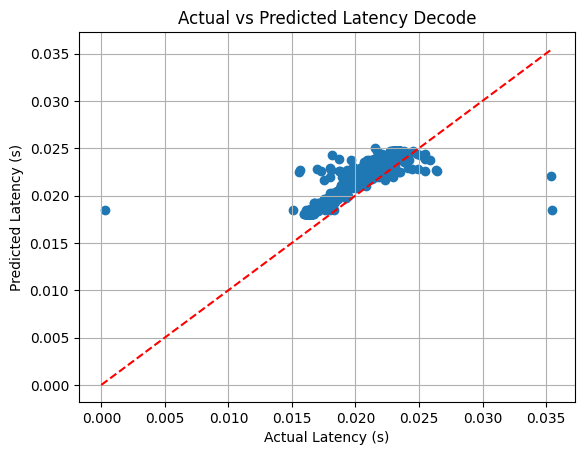

In [ ]:
path = "/export1/liu3882/llm_energy/DistServe/my_script/eval_results_Oct12/tp4_logs_num4k/profiler_logs_seed1k_rps30_freq1980/meta-llama/Llama-3.3-70B-Instruct/H100/1xTP4Prefill_1xTP4/default_log_path/decode_4_Oct13034118/engine_0.csv"
df_decode = pd.read_csv(path)


df_decode['request_ids_iter_tbt_evald'] = df_decode['request_ids_iter_tbt'].apply(eval)
df_decode['inter_token_latencies_iter_evald'] = df_decode['inter_token_latencies_iter'].apply(eval)
df_decode['iter_lat'] = df_decode['inter_token_latencies_iter_evald'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else np.nan)
df_decode['num_prompt_tokens_reqs_evald'] = df_decode['num_prompt_tokens_reqs'].apply(eval)
num_computed_dict = {}
num_computed_tokens_list = [[] for _ in range(len(df_decode))]
#first get num_computed_tokens for each req in each row
for row in df_decode.itertuples():
    if len(row.request_ids_iter_tbt_evald) == 0:
        continue
    else:
        for ID, in_len in zip(row.request_ids_iter_tbt_evald, row.num_prompt_tokens_reqs_evald):
            if ID not in num_computed_dict:
                num_computed_dict[ID] = in_len + 1
            else:
                num_computed_dict[ID] = num_computed_dict[ID] + 1
        num_computed_tokens_list[row.Index] = [num_computed_dict[ID] for ID in row.request_ids_iter_tbt_evald]
df_decode['num_computed_tokens_reqs_evald'] = num_computed_tokens_list

token_lists = df_decode[df_decode['iter_lat'].notna() & df_decode['num_computed_tokens_reqs_evald'].notna()]['num_computed_tokens_reqs_evald'].tolist()
latency_lists = df_decode[df_decode['iter_lat'].notna() & df_decode['num_computed_tokens_reqs_evald'].notna()]['iter_lat'].tolist()

predicted_latencies = [infer_decode(est, tokens, 4, 1830)[0][0][0] for tokens in token_lists]

plt.scatter(latency_lists, predicted_latencies)
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')

plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency Decode")
plt.grid(True)
# plt.xlim(0, 0.05)
# plt.ylim(0, 0.05)
plt.show()



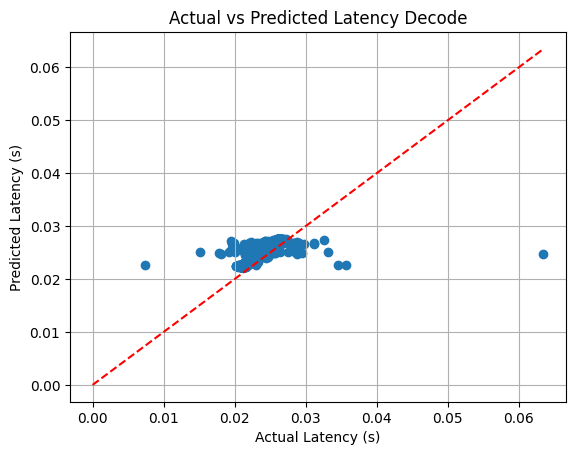

In [ ]:
path = "/export1/liu3882/llm_energy/DistServe/my_script/eval_results_Oct12/tp4_logs_num4k/profiler_logs_seed1k_rps15_freq1080/meta-llama/Llama-3.3-70B-Instruct/H100/1xTP4Prefill_1xTP4/default_log_path/decode_4_Oct13041652/engine_0.csv"
df_decode = pd.read_csv(path)


df_decode['request_ids_iter_tbt_evald'] = df_decode['request_ids_iter_tbt'].apply(eval)
df_decode['inter_token_latencies_iter_evald'] = df_decode['inter_token_latencies_iter'].apply(eval)
df_decode['iter_lat'] = df_decode['inter_token_latencies_iter_evald'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else np.nan)
df_decode['num_prompt_tokens_reqs_evald'] = df_decode['num_prompt_tokens_reqs'].apply(eval)
num_computed_dict = {}
num_computed_tokens_list = [[] for _ in range(len(df_decode))]
#first get num_computed_tokens for each req in each row
for row in df_decode.itertuples():
    if len(row.request_ids_iter_tbt_evald) == 0:
        continue
    else:
        for ID, in_len in zip(row.request_ids_iter_tbt_evald, row.num_prompt_tokens_reqs_evald):
            if ID not in num_computed_dict:
                num_computed_dict[ID] = in_len + 1
            else:
                num_computed_dict[ID] = num_computed_dict[ID] + 1
        num_computed_tokens_list[row.Index] = [num_computed_dict[ID] for ID in row.request_ids_iter_tbt_evald]
df_decode['num_computed_tokens_reqs_evald'] = num_computed_tokens_list

token_lists = df_decode[df_decode['iter_lat'].notna() & df_decode['num_computed_tokens_reqs_evald'].notna()]['num_computed_tokens_reqs_evald'].tolist()
latency_lists = df_decode[df_decode['iter_lat'].notna() & df_decode['num_computed_tokens_reqs_evald'].notna()]['iter_lat'].tolist()

predicted_latencies = [infer_decode(est, tokens, 4, 1080)[0][0][0] for tokens in token_lists]

plt.scatter(latency_lists, predicted_latencies)
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')

plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency Decode")
plt.grid(True)
# plt.xlim(0, 0.05)
# plt.ylim(0, 0.05)
plt.show()



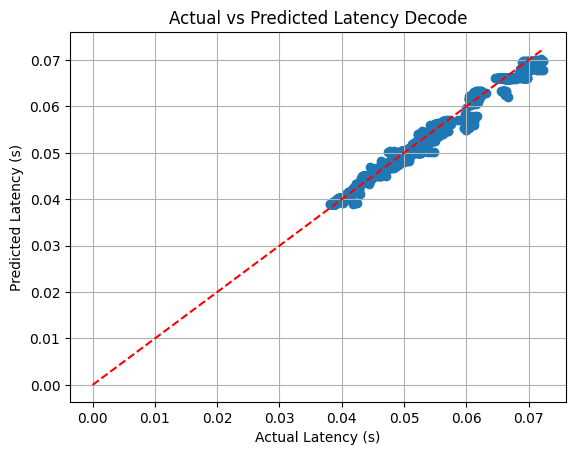

In [ ]:
path = "/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/round_robin_balancing/synthetic_wo_margin/OURS_DEC26_B5_6/decode_2_Dec27215749/engine_0.csv"
df_decode = pd.read_csv(path)


df_decode['request_ids_iter_tbt_evald'] = df_decode['request_ids_iter_tbt'].apply(eval)
df_decode['inter_token_latencies_iter_evald'] = df_decode['inter_token_latencies_iter'].apply(eval)
df_decode['iter_lat'] = df_decode['inter_token_latencies_iter_evald'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else np.nan)
df_decode['num_prompt_tokens_reqs_evald'] = df_decode['num_prompt_tokens_reqs'].apply(eval)
num_computed_dict = {}
num_computed_tokens_list = [[] for _ in range(len(df_decode))]
#first get num_computed_tokens for each req in each row
for row in df_decode.itertuples():
    if len(row.request_ids_iter_tbt_evald) == 0:
        continue
    else:
        for ID, in_len in zip(row.request_ids_iter_tbt_evald, row.num_prompt_tokens_reqs_evald):
            if ID not in num_computed_dict:
                num_computed_dict[ID] = in_len + 1
            else:
                num_computed_dict[ID] = num_computed_dict[ID] + 1
        num_computed_tokens_list[row.Index] = [num_computed_dict[ID] for ID in row.request_ids_iter_tbt_evald]
df_decode['num_computed_tokens_reqs_evald'] = num_computed_tokens_list

token_lists = df_decode[df_decode['iter_lat'].notna() & df_decode['num_computed_tokens_reqs_evald'].notna()]['num_computed_tokens_reqs_evald'].tolist()
latency_lists = df_decode[df_decode['iter_lat'].notna() & df_decode['num_computed_tokens_reqs_evald'].notna()]['iter_lat'].tolist()

predicted_latencies = [infer_decode(est, tokens, 4, 360)[0][0][0] for tokens in token_lists]

plt.scatter(latency_lists, predicted_latencies)
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')

plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency Decode")
plt.grid(True)
# plt.xlim(0, 0.05)
# plt.ylim(0, 0.05)
plt.show()



## TP8


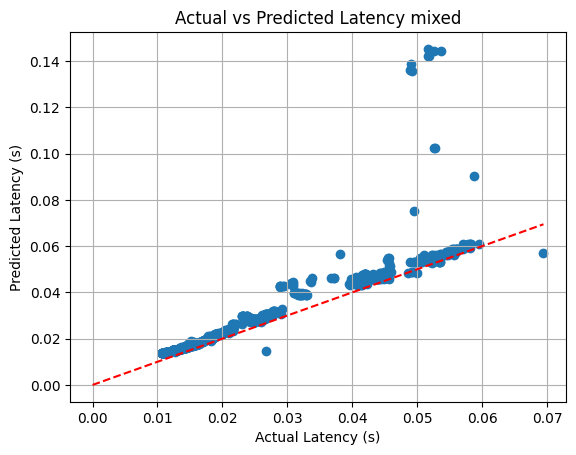

In [ ]:
path = "/export2/obasit/ClusterLevelServing/vllm_profiler_logs/batch_shapes_traces_and_runs/shape runs/burst0.5_randomly_gen2k_tp8_1830/engine_0.csv"
df_decode = pd.read_csv(path)


df_decode['inter_token_latencies_iter_evald'] = df_decode['inter_token_latencies_iter'].apply(eval)
df_decode['iter_lat'] = df_decode['inter_token_latencies_iter_evald'].apply(lambda x: x[1] if isinstance(x, list) and len(x) > 1 else np.nan)
df_decode['num_prompt_tokens_reqs_evald'] = df_decode['num_prompt_tokens_reqs'].apply(eval)
df_decode['max_num_generation_tokens_iter_evald'] = df_decode['max_num_generation_tokens_iter'].apply(eval)

prefill_token_lists = []
decode_token_lists = []
latency_lists = []
for row in df_decode.itertuples():
    if len(row.num_prompt_tokens_reqs_evald) == 0 or \
        len(row.max_num_generation_tokens_iter_evald) == 0 or \
        len(row.num_prompt_tokens_reqs_evald) != len(row.max_num_generation_tokens_iter_evald) \
        or pd.isna(row.iter_lat):
        continue
    else:
        prefill_lens = []
        decode_lens = []
        
        for i, (prompt_len, gen_tok) in enumerate(zip(row.num_prompt_tokens_reqs_evald, row.max_num_generation_tokens_iter_evald)):
            if gen_tok == 1:
                # This is a prefill request
                prefill_lens.append(prompt_len)
            else:
                # This is a decode request
                # Total KV cache size = prompt_len + gen_tokens
                decode_lens.append(prompt_len + gen_tok)
        if len(prefill_lens) == 0 and len(decode_lens) > 0:
            prefill_token_lists.append(prefill_lens)
            decode_token_lists.append(decode_lens)
            latency_lists.append(row.iter_lat)

predicted_latencies = [infer_decode(est, tokens=decode_tokens, tp=8, freq=1830)[0][0][0] for prefill_tokens, decode_tokens in zip(prefill_token_lists, decode_token_lists)]
plt.scatter(latency_lists, predicted_latencies)
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')

plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency mixed")
plt.grid(True)
# plt.xlim(0, 0.05)
# plt.ylim(0, 0.05)
plt.show()



# Mixed

## TP2

/home/obasit/miniconda3/envs/vllm/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/obasit/miniconda3/envs/vllm/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/obasit/miniconda3/envs/vllm/lib/python3.11/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/obasit/miniconda3/envs/vllm/lib/python3.11/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/obasit/miniconda3/envs/vllm/lib/python3.11/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


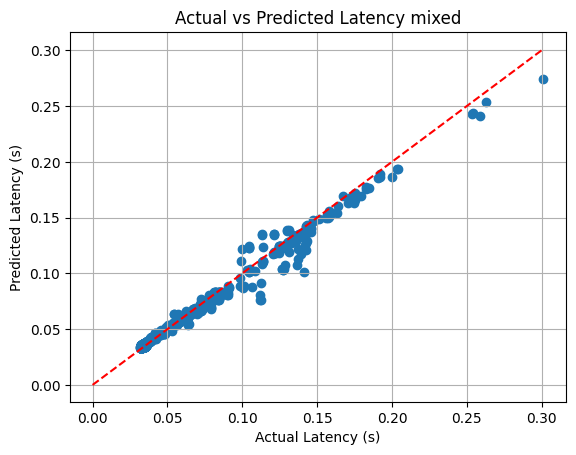

In [59]:
path = "/export2/obasit/ClusterLevelServing/vllm_profiler_logs/batch_shapes_traces_and_runs/shape runs/burst0.5_RPS2_reqs1k_seed2_tp2_1080/engine_0.csv"
df_decode = pd.read_csv(path)


df_decode['inter_token_latencies_iter_evald'] = df_decode['inter_token_latencies_iter'].apply(eval)
df_decode['iter_lat'] = df_decode['inter_token_latencies_iter_evald'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else np.nan)
df_decode['num_prompt_tokens_reqs_evald'] = df_decode['num_prompt_tokens_reqs'].apply(eval)
df_decode['max_num_generation_tokens_iter_evald'] = df_decode['max_num_generation_tokens_iter'].apply(eval)

prefill_token_lists = []
decode_token_lists = []
latency_lists = []
for row in df_decode.itertuples():
    if len(row.num_prompt_tokens_reqs_evald) == 0 or \
        len(row.max_num_generation_tokens_iter_evald) == 0 or \
        len(row.num_prompt_tokens_reqs_evald) != len(row.max_num_generation_tokens_iter_evald) \
        or pd.isna(row.iter_lat):
        continue
    else:
        prefill_lens = []
        decode_lens = []
        
        for i, (prompt_len, gen_tok) in enumerate(zip(row.num_prompt_tokens_reqs_evald, row.max_num_generation_tokens_iter_evald)):
            if gen_tok == 1:
                # This is a prefill request
                prefill_lens.append(prompt_len)
            else:
                # This is a decode request
                # Total KV cache size = prompt_len + gen_tokens
                decode_lens.append(prompt_len + gen_tok)
        prefill_token_lists.append(prefill_lens)
        decode_token_lists.append(decode_lens)
        latency_lists.append(row.iter_lat)

predicted_latencies = [infer_mixed(est, prefill_tokens=prefill_tokens, decode_tokens=decode_tokens, tp=2, freq=1080)[0][0][0] for prefill_tokens, decode_tokens in zip(prefill_token_lists, decode_token_lists)]
plt.scatter(latency_lists, predicted_latencies)
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')

plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency mixed")
plt.grid(True)
# plt.xlim(0, 0.05)
# plt.ylim(0, 0.05)
plt.show()

/home/obasit/miniconda3/envs/vllm/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/obasit/miniconda3/envs/vllm/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/obasit/miniconda3/envs/vllm/lib/python3.11/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/obasit/miniconda3/envs/vllm/lib/python3.11/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/obasit/miniconda3/envs/vllm/lib/python3.11/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


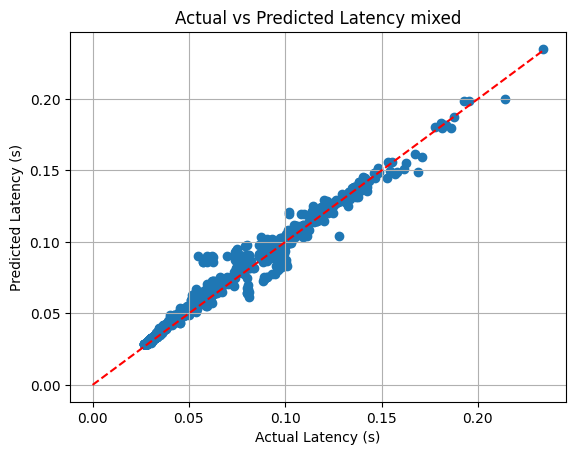

In [62]:
path = "/export2/obasit/ClusterLevelServing/vllm_profiler_logs/batch_shapes_traces_and_runs/shape runs/burst0.5_RPS5_reqs3k_seed5_tp2_1830/engine_0.csv"
df_decode = pd.read_csv(path)


df_decode['inter_token_latencies_iter_evald'] = df_decode['inter_token_latencies_iter'].apply(eval)
df_decode['iter_lat'] = df_decode['inter_token_latencies_iter_evald'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else np.nan)
df_decode['num_prompt_tokens_reqs_evald'] = df_decode['num_prompt_tokens_reqs'].apply(eval)
df_decode['max_num_generation_tokens_iter_evald'] = df_decode['max_num_generation_tokens_iter'].apply(eval)

prefill_token_lists = []
decode_token_lists = []
latency_lists = []
for row in df_decode.itertuples():
    if len(row.num_prompt_tokens_reqs_evald) == 0 or \
        len(row.max_num_generation_tokens_iter_evald) == 0 or \
        len(row.num_prompt_tokens_reqs_evald) != len(row.max_num_generation_tokens_iter_evald) \
        or pd.isna(row.iter_lat):
        continue
    else:
        prefill_lens = []
        decode_lens = []
        
        for i, (prompt_len, gen_tok) in enumerate(zip(row.num_prompt_tokens_reqs_evald, row.max_num_generation_tokens_iter_evald)):
            if gen_tok == 1:
                # This is a prefill request
                prefill_lens.append(prompt_len)
            else:
                # This is a decode request
                # Total KV cache size = prompt_len + gen_tokens
                decode_lens.append(prompt_len + gen_tok)
        prefill_token_lists.append(prefill_lens)
        decode_token_lists.append(decode_lens)
        latency_lists.append(row.iter_lat)

predicted_latencies = [infer_mixed(est, prefill_tokens=prefill_tokens, decode_tokens=decode_tokens, tp=2, freq=1830)[0][0][0] for prefill_tokens, decode_tokens in zip(prefill_token_lists, decode_token_lists)]
plt.scatter(latency_lists, predicted_latencies)
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')

plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency mixed")
plt.grid(True)
# plt.xlim(0, 0.05)
# plt.ylim(0, 0.05)
plt.show()

## TP4

/home/obasit/miniconda3/envs/vllm/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/obasit/miniconda3/envs/vllm/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/obasit/miniconda3/envs/vllm/lib/python3.11/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/obasit/miniconda3/envs/vllm/lib/python3.11/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/obasit/miniconda3/envs/vllm/lib/python3.11/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


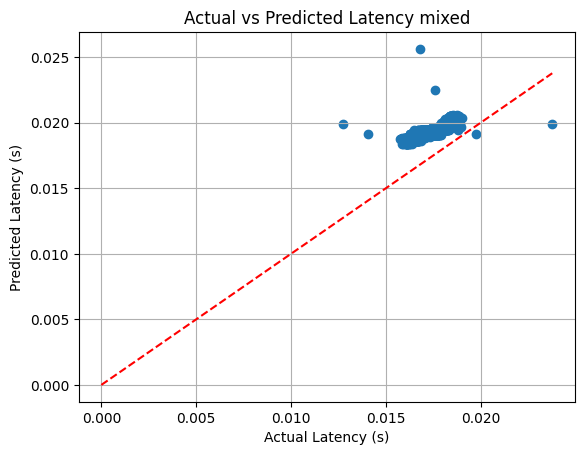

In [ ]:
path = "/export2/obasit/ClusterLevelServing/vllm_profiler_logs/batch_shapes_traces_and_runs/shape runs/burst0.5_RPS5_reqs3k_seed5_tp4_1830/engine_0.csv"
df_decode = pd.read_csv(path)


df_decode['inter_token_latencies_iter_evald'] = df_decode['inter_token_latencies_iter'].apply(eval)
df_decode['iter_lat'] = df_decode['inter_token_latencies_iter_evald'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else np.nan)
df_decode['num_prompt_tokens_reqs_evald'] = df_decode['num_prompt_tokens_reqs'].apply(eval)
df_decode['max_num_generation_tokens_iter_evald'] = df_decode['max_num_generation_tokens_iter'].apply(eval)

prefill_token_lists = []
decode_token_lists = []
latency_lists = []
last_skipped = False
for row in df_decode.itertuples():
    if last_skipped:
        last_skipped = False
        continue
    if len(row.num_prompt_tokens_reqs_evald) == 0 or \
        len(row.max_num_generation_tokens_iter_evald) == 0 or \
        len(row.num_prompt_tokens_reqs_evald) != len(row.max_num_generation_tokens_iter_evald) \
        or pd.isna(row.iter_lat):
        continue
    else:
        prefill_lens = []
        decode_lens = []
        
        for i, (prompt_len, gen_tok) in enumerate(zip(row.num_prompt_tokens_reqs_evald, row.max_num_generation_tokens_iter_evald)):
            if gen_tok == 1:
                # This is a prefill request
                prefill_lens.append(prompt_len)
            else:
                # This is a decode request
                # Total KV cache size = prompt_len + gen_tokens
                decode_lens.append(prompt_len + gen_tok)
        

        if (np.sum(prefill_lens) + len(decode_lens)) > 2048:
            last_skipped = True
            continue
        
        if len(decode_lens) > 0 and len(prefill_lens) == 0:
            prefill_token_lists.append(prefill_lens)
            decode_token_lists.append(decode_lens)
            latency_lists.append(row.iter_lat)

predicted_latencies = [infer_mixed(est, prefill_tokens=prefill_tokens, decode_tokens=decode_tokens, tp=4, freq=1830)[0][0][0] for prefill_tokens, decode_tokens in zip(prefill_token_lists, decode_token_lists)]
plt.scatter(latency_lists, predicted_latencies)
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')

plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency mixed")
plt.grid(True)
# plt.xlim(0, 0.05)
# plt.ylim(0, 0.05)
plt.show()



/home/obasit/miniconda3/envs/vllm/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/obasit/miniconda3/envs/vllm/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/obasit/miniconda3/envs/vllm/lib/python3.11/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/obasit/miniconda3/envs/vllm/lib/python3.11/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/obasit/miniconda3/envs/vllm/lib/python3.11/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


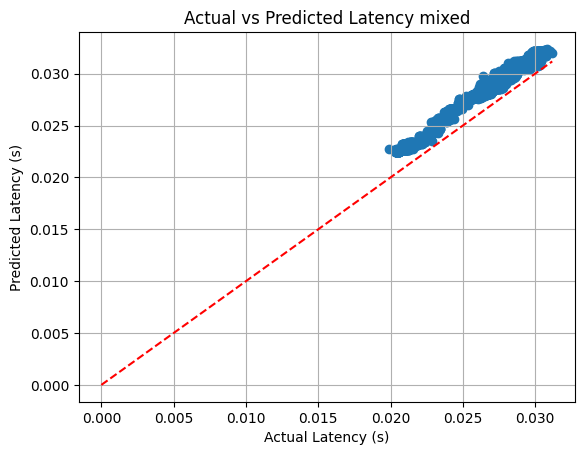

In [ ]:
path = "/export2/obasit/ClusterLevelServing/vllm_profiler_logs/batch_shapes_traces_and_runs/shape runs/burst0.5_RPS15_reqs9k_seed15_tp4_1080/engine_0.csv"
df_decode = pd.read_csv(path)


df_decode['inter_token_latencies_iter_evald'] = df_decode['inter_token_latencies_iter'].apply(eval)
df_decode['iter_lat'] = df_decode['inter_token_latencies_iter_evald'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else np.nan)
df_decode['num_prompt_tokens_reqs_evald'] = df_decode['num_prompt_tokens_reqs'].apply(eval)
df_decode['max_num_generation_tokens_iter_evald'] = df_decode['max_num_generation_tokens_iter'].apply(eval)

prefill_token_lists = []
decode_token_lists = []
latency_lists = []
last_skipped = False
indexes = []
for row in df_decode.itertuples():
    if last_skipped:
        last_skipped = False
        continue
    if len(row.num_prompt_tokens_reqs_evald) == 0 or \
        len(row.max_num_generation_tokens_iter_evald) == 0 or \
        len(row.num_prompt_tokens_reqs_evald) != len(row.max_num_generation_tokens_iter_evald) \
        or pd.isna(row.iter_lat):
        continue
    else:
        prefill_lens = []
        decode_lens = []
        
        for i, (prompt_len, gen_tok) in enumerate(zip(row.num_prompt_tokens_reqs_evald, row.max_num_generation_tokens_iter_evald)):
            if gen_tok == 1:
                # This is a prefill request
                prefill_lens.append(prompt_len)
            else:
                # This is a decode request
                # Total KV cache size = prompt_len + gen_tokens
                decode_lens.append(prompt_len + gen_tok)
        

        if (np.sum(prefill_lens) + len(decode_lens)) > 2048:
            last_skipped = True
            continue
        
        if len(decode_lens) > 0 and len(prefill_lens) == 0:
            prefill_token_lists.append(prefill_lens)
            decode_token_lists.append(decode_lens)
            latency_lists.append(row.iter_lat)
            indexes.append(row.Index)

predicted_latencies = [infer_mixed(est, prefill_tokens=prefill_tokens, decode_tokens=decode_tokens, tp=4, freq=1080)[0][0][0] for prefill_tokens, decode_tokens in zip(prefill_token_lists, decode_token_lists)]
plt.scatter(latency_lists, predicted_latencies)
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')

plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency mixed")
plt.grid(True)
# plt.xlim(0, 0.05)
# plt.ylim(0, 0.05)
plt.show()



## TP8

/home/obasit/miniconda3/envs/vllm/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/obasit/miniconda3/envs/vllm/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/obasit/miniconda3/envs/vllm/lib/python3.11/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/obasit/miniconda3/envs/vllm/lib/python3.11/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/obasit/miniconda3/envs/vllm/lib/python3.11/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


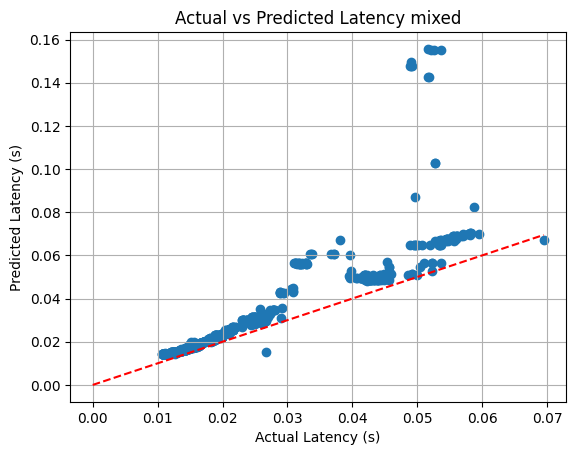

In [ ]:
path = "/export2/obasit/ClusterLevelServing/vllm_profiler_logs/batch_shapes_traces_and_runs/shape runs/burst0.5_randomly_gen2k_tp8_1830/engine_0.csv"
df_decode = pd.read_csv(path)


df_decode['inter_token_latencies_iter_evald'] = df_decode['inter_token_latencies_iter'].apply(eval)
df_decode['iter_lat'] = df_decode['inter_token_latencies_iter_evald'].apply(lambda x: x[1] if isinstance(x, list) and len(x) > 1 else np.nan)
df_decode['num_prompt_tokens_reqs_evald'] = df_decode['num_prompt_tokens_reqs'].apply(eval)
df_decode['max_num_generation_tokens_iter_evald'] = df_decode['max_num_generation_tokens_iter'].apply(eval)

prefill_token_lists = []
decode_token_lists = []
latency_lists = []
last_skipped = False
for row in df_decode.itertuples():
    if last_skipped:
        last_skipped = False
        continue
    if len(row.num_prompt_tokens_reqs_evald) == 0 or \
        len(row.max_num_generation_tokens_iter_evald) == 0 or \
        len(row.num_prompt_tokens_reqs_evald) != len(row.max_num_generation_tokens_iter_evald) \
        or pd.isna(row.iter_lat):
        continue
    else:
        prefill_lens = []
        decode_lens = []
        
        for i, (prompt_len, gen_tok) in enumerate(zip(row.num_prompt_tokens_reqs_evald, row.max_num_generation_tokens_iter_evald)):
            if gen_tok == 1:
                # This is a prefill request
                prefill_lens.append(prompt_len)
            else:
                # This is a decode request
                # Total KV cache size = prompt_len + gen_tokens
                decode_lens.append(prompt_len + gen_tok)
        

        if (np.sum(prefill_lens) + len(decode_lens)) > 2048:
            last_skipped = True
            continue
        
        if len(decode_lens) > 0 and len(prefill_lens) == 0:
            prefill_token_lists.append(prefill_lens)
            decode_token_lists.append(decode_lens)
            latency_lists.append(row.iter_lat)

predicted_latencies = [infer_mixed(est, prefill_tokens=prefill_tokens, decode_tokens=decode_tokens, tp=8, freq=1830)[0][0][0] for prefill_tokens, decode_tokens in zip(prefill_token_lists, decode_token_lists)]
plt.scatter(latency_lists, predicted_latencies)
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')

plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency mixed")
plt.grid(True)
# plt.xlim(0, 0.05)
# plt.ylim(0, 0.05)
plt.show()



In [ ]:
df_decode['predicted_iter_lat'] = np.nan
for pred, real in zip(predicted_latencies, latency_lists):
    df_decode.loc[df_decode['iter_lat'] == real, 'predicted_iter_lat'] = pred
df_decode['abs_error'] = abs(df_decode['predicted_iter_lat'] - df_decode['iter_lat'])
df_decode.dropna().to_csv("check.csv")